# 1.Introduction




Analyzing the Correlation between Book Pricing and User Ratings from dataset from dataset "bestsellers with categories.csv"(2009-2019)








# 2. Data Loading & Library Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('bestsellers with categories.csv')

# 3. Understanding the Dataset

In [3]:
df.head()

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


In [4]:
df.tail()

,Name,Author,User Rating,Reviews,Price,Year,Genre
545,Wrecking Ball (Diary of a Wimpy Kid Book 14),Jeff Kinney,4.9,9413,8,2019,Fiction
546,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2016,Non Fiction
547,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2017,Non Fiction
548,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2018,Non Fiction
549,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2019,Non Fiction


In [5]:
df.describe()

,User Rating,Reviews,Price,Year
count,550.000000,550.000000,550.000000,550.000000
mean,4.618364,11953.281818,13.100000,2014.000000
std,0.226980,11731.132017,10.842262,3.165156
min,3.300000,37.000000,0.000000,2009.000000
25%,4.500000,4058.000000,7.000000,2011.000000
50%,4.700000,8580.000000,11.000000,2014.000000
75%,4.800000,17253.250000,16.000000,2017.000000
max,4.900000,87841.000000,105.000000,2019.000000


In [6]:
df.shape

(550, 7)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         550 non-null    object 
 1   Author       550 non-null    object 
 2   User Rating  550 non-null    float64
 3   Reviews      550 non-null    int64  
 4   Price        550 non-null    int64  
 5   Year         550 non-null    int64  
 6   Genre        550 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 30.2+ KB


In [8]:
df.columns

Index(['Name', 'Author', 'User Rating', 'Reviews', 'Price', 'Year', 'Genre'], dtype='object')

Overall, the analysis indicates that dataframe consists of 550 bookes and attributs like Name, Author, User Rating, Reviews, Price, Year, Genre.

4.Data cleaning

In [9]:
df.isnull().sum()

,0
Name,0
Author,0
User Rating,0
Reviews,0
Price,0
Year,0
Genre,0


Hence no null values

In [10]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

Dublicate values removed

# 5. univariance analysis

In [11]:
df['Year'].value_counts()

,count
Year,
2016,50
2011,50
2018,50
2017,50
2019,50
2014,50
2010,50
2009,50
2015,50


Hence, every years top 50 best selling book from 2009 to 2019

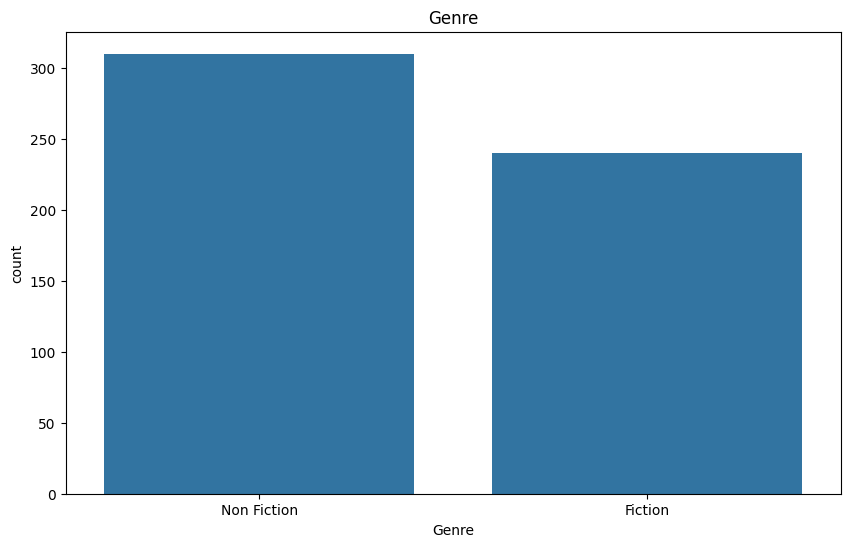

In [12]:
plt.figure(figsize=(10,6))

sns.countplot(x=df.Genre)
plt.title('Genre')
plt.show()

This plot shows that Non Frction Dominates Fiction

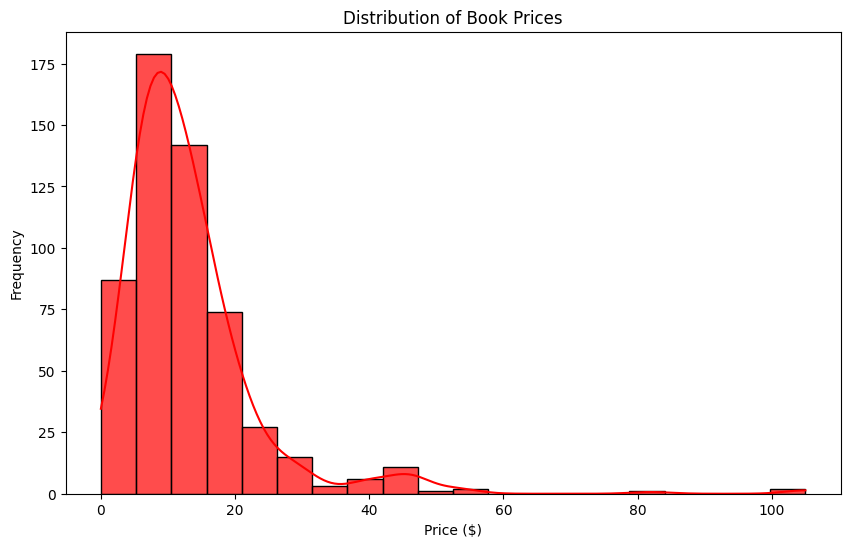

In [13]:
plt.figure(figsize=(10,6))
sns.histplot(df.Price, kde=True, bins=20, color='red', edgecolor='black',alpha=0.7)
plt.title('Distribution of Book Prices')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.show()

This plot shows that best selling books are in the price range of 0-20

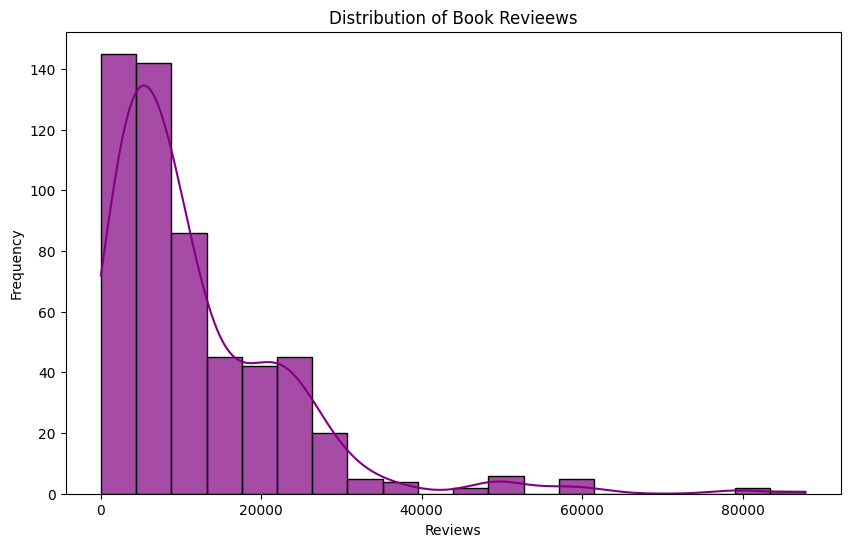

In [14]:
plt.figure(figsize=(10,6))
sns.histplot(df.Reviews,kde=True, bins=20, color='purple', edgecolor='black',alpha=0.7)
plt.title('Distribution of Book Revieews')
plt.xlabel('Reviews')
plt.ylabel('Frequency')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

This plot shows that books with 0-3000 ratings are more than 3000-8000

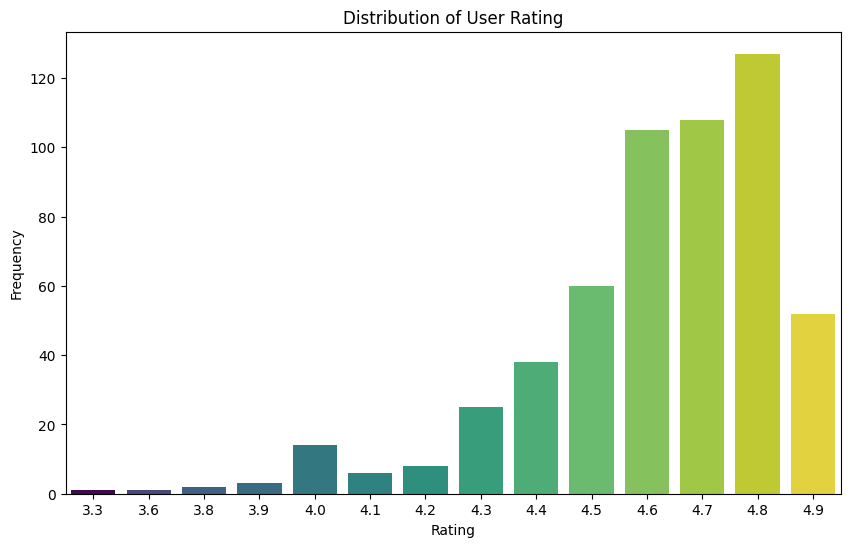

In [15]:
plt.figure(figsize=(10,6))
sns.countplot(x='User Rating', data=df, hue='User Rating', palette='viridis', legend=False)
plt.title('Distribution of User Rating')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

This plot shows that books with 4.8 rating are common

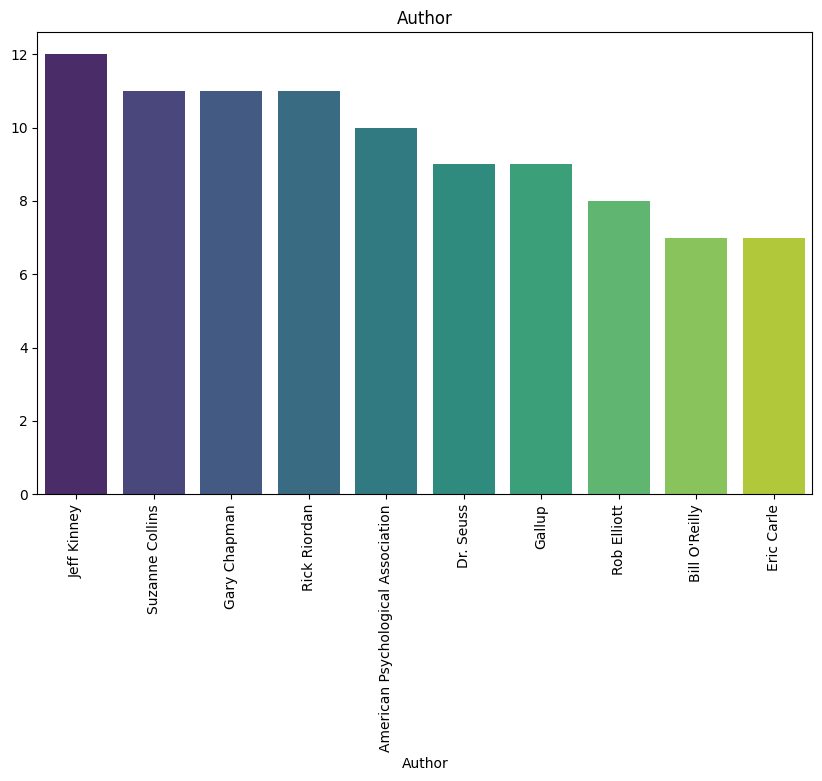

In [16]:
plt.figure(figsize=(10,6))
d=df['Author'].value_counts().head(10)
sns.barplot(x=d.index,hue=d.index, y=d.values, palette='viridis')
plt.xticks(rotation=90)
plt.title('Author')
plt.show()

This plot shows the top 10 auther who got most books as best selling

# 6. bivariance analysis

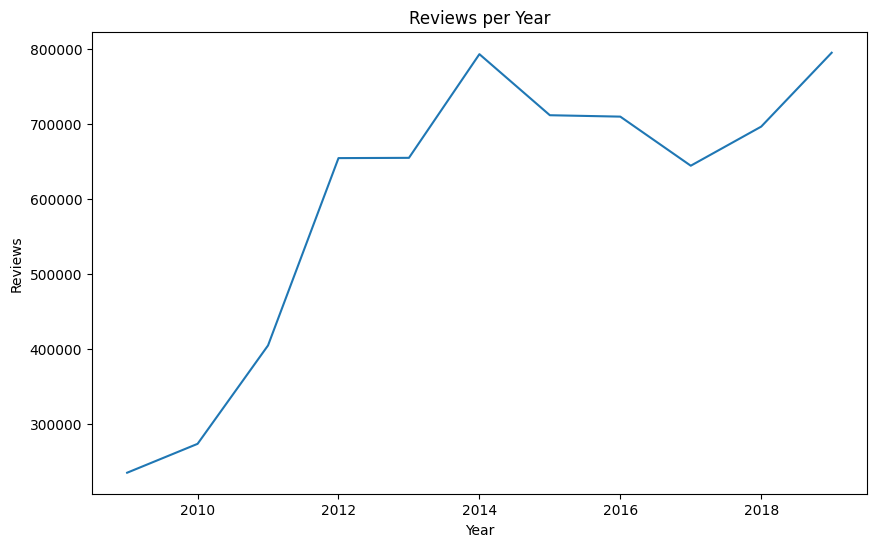

In [17]:
plt.figure(figsize=(10,6))
df.groupby('Year')['Reviews'].sum().plot()
plt.title('Reviews per Year')
plt.xlabel('Year')
plt.ylabel('Reviews')
plt.show()

This plot shows that Reviews in the span of 2009 to 2019

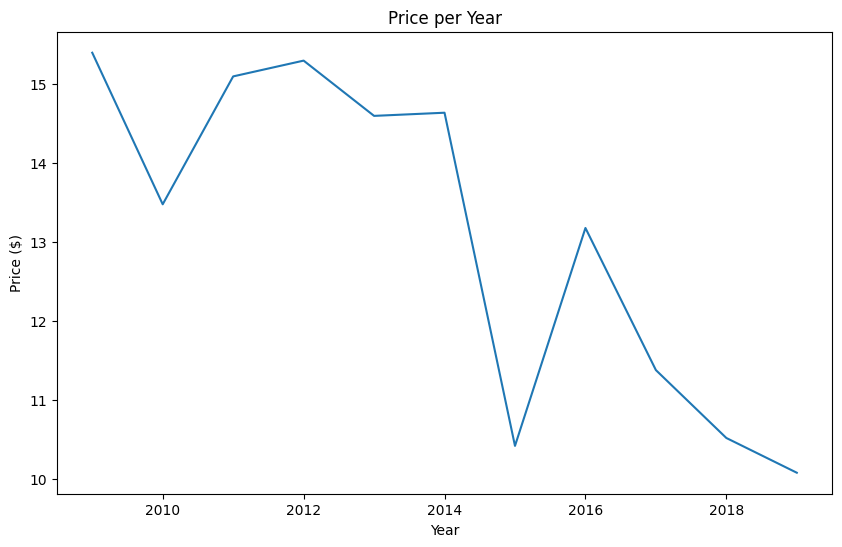

In [18]:
plt.figure(figsize=(10,6))
df.groupby('Year')['Price'].mean().plot()
plt.title('Price per Year')
plt.xlabel('Year')
plt.ylabel('Price ($)')
plt.show()

This plot shows that price is decrecing from 2009 -2019

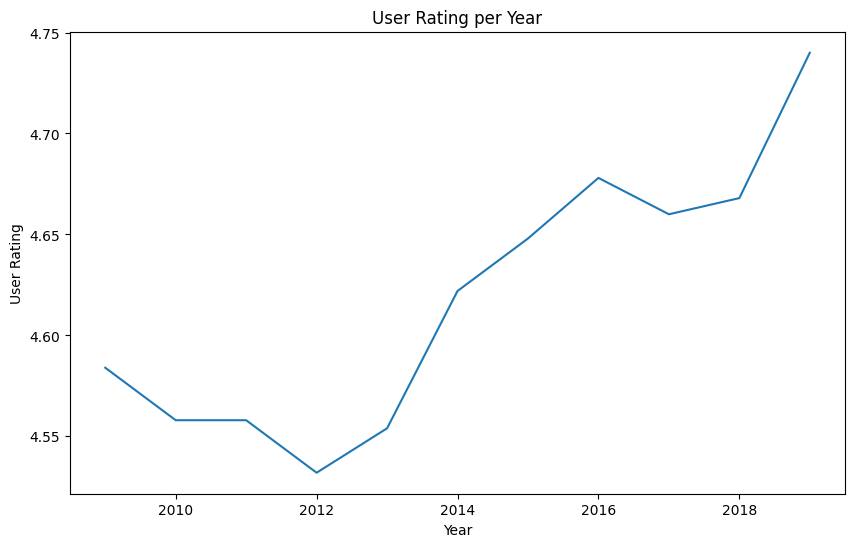

In [19]:
plt.figure(figsize=(10,6))

df.groupby('Year')['User Rating'].mean().plot()
plt.title('User Rating per Year')
plt.xlabel('Year')
plt.ylabel('User Rating')
plt.show()

This plot shows that more user are getting satisfied in sapn of time

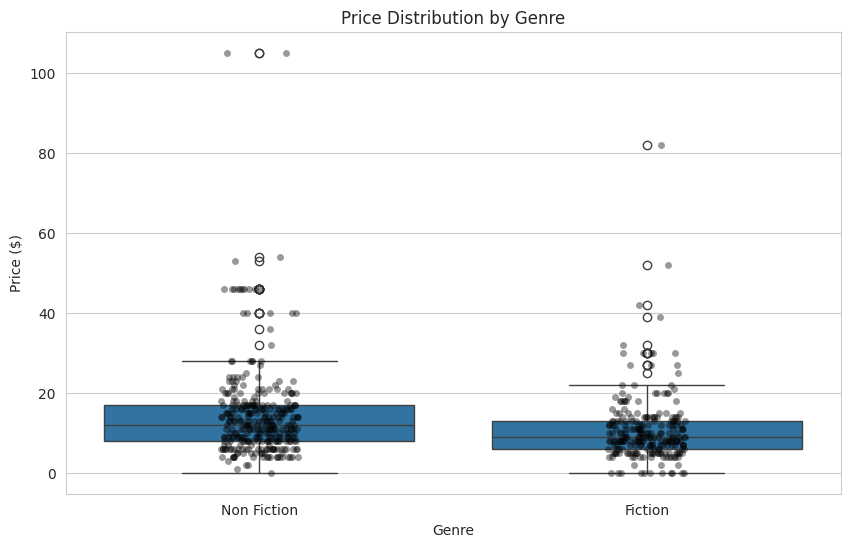

In [20]:
sns.set_style("whitegrid")
plt.figure(figsize=(10,6))
sns.boxplot(x='Genre', y='Price', data=df)
sns.stripplot(x='Genre', y='Price', data=df, color='black', alpha=0.4, jitter=True)
plt.title('Price Distribution by Genre')
plt.xlabel('Genre')
plt.ylabel('Price ($)')
plt.show()


This plot shows the price distribution based on Genre, non fiction seems to be pricely then fiction

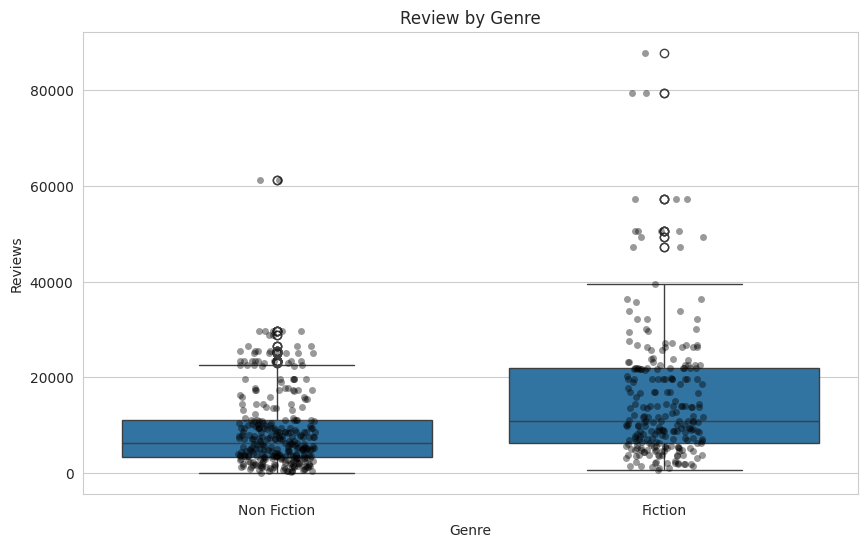

In [21]:
sns.set_style("whitegrid")
plt.figure(figsize=(10,6))

sns.boxplot(x='Genre', y='Reviews' , data=df, showfliers=True)
sns.stripplot(
    x='Genre',
    y='Reviews',
    data=df,
    color='black',
    alpha=0.4,
    jitter=True)
plt.title('Review by Genre')
plt.xlabel('Genre')
plt.ylabel('Reviews')
plt.show()


This plot shows the reviews based on Genre, non fiction seems to have less reviews then fiction

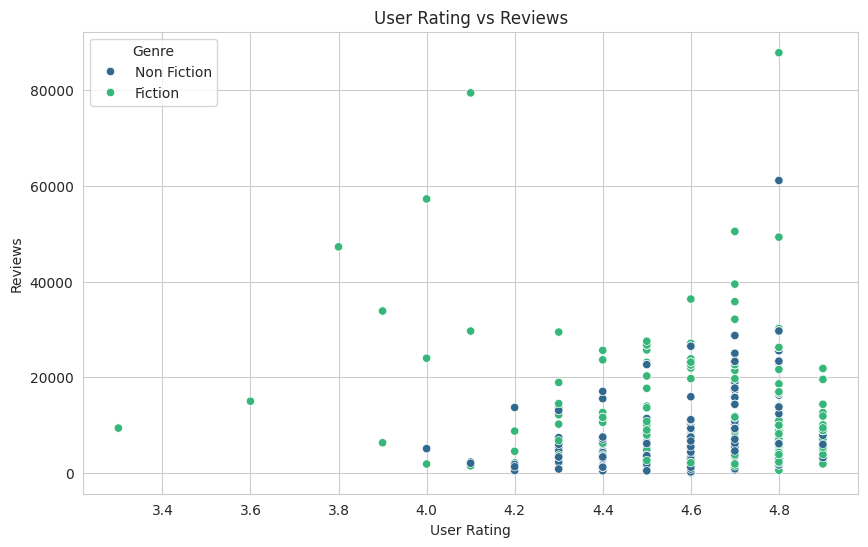

In [22]:
plt.figure(figsize=(10,6))

sns.scatterplot(x='User Rating', y='Reviews', data=df, hue='Genre', palette='viridis')
plt.title('User Rating vs Reviews')
plt.xlabel('User Rating')
plt.ylabel('Reviews')
plt.show()

This plot shows the fiction has more one time hits but non fiction seems to have more consistant and high rating

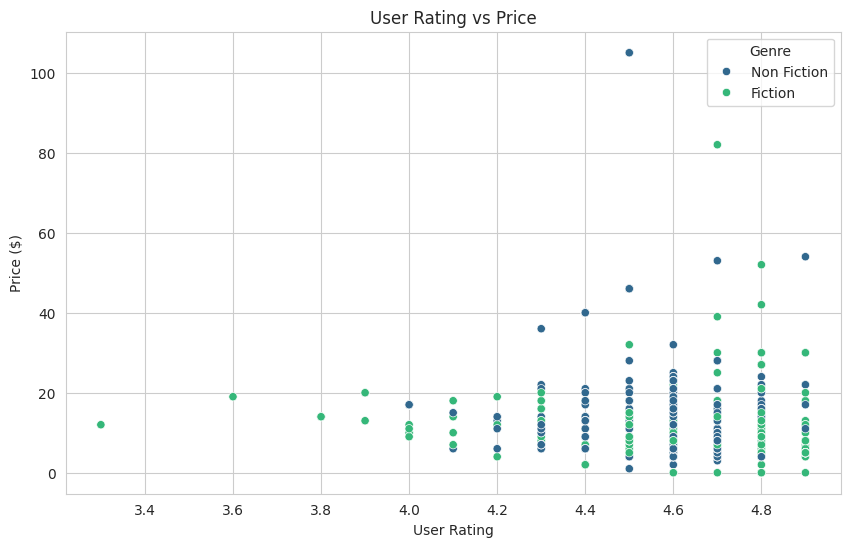

In [23]:
sns.set_style("whitegrid")
plt.figure(figsize=(10,6))

sns.scatterplot(x='User Rating', y='Price', data=df, hue='Genre', palette='viridis')
plt.title('User Rating vs Price')
plt.xlabel('User Rating')
plt.ylabel('Price ($)')
plt.show()

This plot shows the non fiction has good rating as well as having decent price, on the other hand fiction has some low ratings based on price

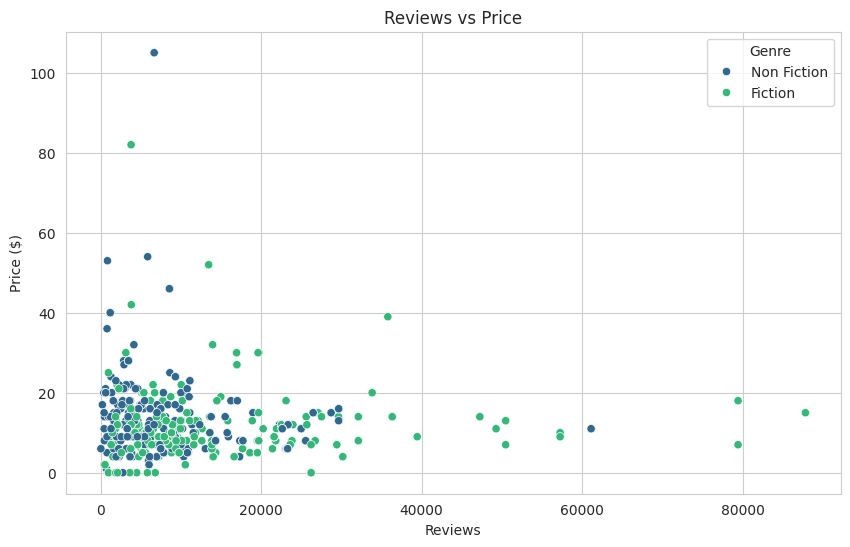

In [24]:
sns.set_style("whitegrid")
plt.figure(figsize=(10,6))
sns.scatterplot(x='Reviews', y='Price', data=df, hue='Genre', palette='viridis')
plt.title('Reviews vs Price')
plt.xlabel('Reviews')
plt.ylabel('Price ($)')
plt.show()

This plot shows the price range dosent affect the reviews

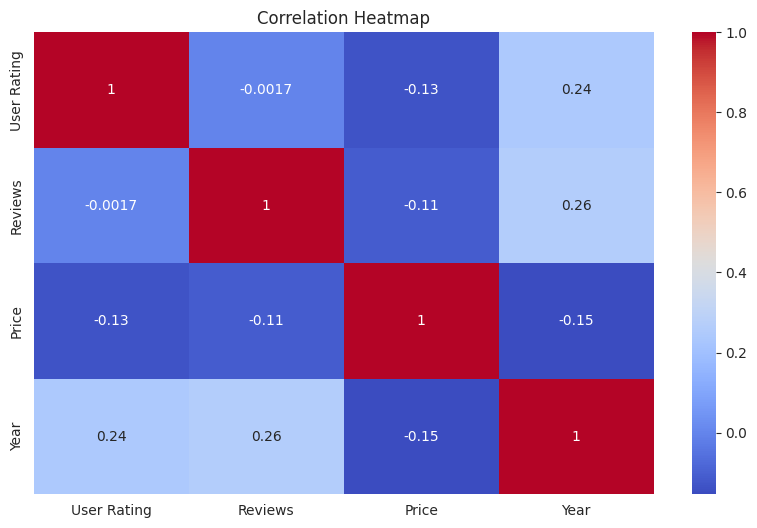

In [25]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

This plot shows the Correlation heatmap.

# 7. conclusion
Overall, the dataset is dominated by a limited number of genres, with non-fiction books appearing slightly more frequently than fiction, indicating a strong reader interest in informational and self-development content. The analysis of user ratings shows that most books are highly rated (generally above 4.5), suggesting that bestselling books tend to maintain consistently good quality.

From the reviews distribution, it is evident that the data is highly right-skewed, where a small number of books receive extremely high numbers of reviews while the majority have moderate engagement. This indicates the presence of a few highly popular or viral titles.

Price analysis shows that most books are reasonably priced within a narrow range, and there is no strong evidence that higher-priced books receive more reviews or better ratings. This suggests that price is not a primary factor influencing popularity.

Bivariate analysis highlights that there is little to no strong correlation between reviews, ratings, and price, meaning that a book's popularity (reviews) does not necessarily guarantee higher ratings or depend on pricing. Additionally, trends over the years indicate that reader engagement has generally increased over time, as seen from rising review counts.

Multivariate analysis further reveals that non-fiction books tend to show greater variability in reviews, with some titles achieving extremely high popularity, while fiction books maintain more consistent performanc